In [26]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import geopandas as gpd

from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions

if not os.path.exists("./stan"):
    os.mkdir("./stan")

In [32]:
df = pd.read_csv("/Users/tommasobaresi/Desktop/Bayesian-Statistics-Project/Bayesian-Statistics-Project/data/updated_data.csv")
df["ecec_diffusion"] = df["ecec_diffusion"].fillna(df["ecec_diffusion"].median())
df

,prov_name,fem_empl_rate,population,unempl_rate,part_rate,empl_rate,empl_growth,inact_rate,fem_edu_rate,male_edu_rate,...,GERD_total_intramural,public_coverage,private_coverage,other_percapita_public_expenditure,other_percapita_user_contrib,other_per_capita_expenditure,fem_maj_empl_rate,wr_men,ecec_diffusion,empl_gap
0,Oristano,43.5,151655,13.6,0.044271,51.4,0.000000,40.5,0.149833,0.101537,...,0.83,4.025045,5.813953,1186.043828,26.765653,1212.809481,4.873680,59.093522,34.5,0.74
1,Modena,65.9,701751,5.1,0.058595,71.0,4.487179,25.2,0.194783,0.156378,...,2.16,7.078254,5.112072,597.383405,23.532704,621.571503,4.259347,76.049129,97.9,0.87
2,Catanzaro,34.9,343673,13.6,0.042536,47.0,0.943396,45.6,0.198824,0.163084,...,0.59,1.335648,6.411113,171.707359,0.000000,171.707359,3.975738,59.382716,17.5,0.59
3,Rimini,57.9,338369,6.7,0.054481,65.2,0.000000,30.1,0.209848,0.165499,...,2.16,6.282562,3.984064,225.224487,0.444376,225.668863,4.708083,72.714210,77.8,0.80
4,Teramo,55.4,299646,6.3,0.051762,62.5,1.666667,33.3,0.197518,0.154127,...,1.14,4.961958,4.134965,126.776381,18.014720,144.791102,2.794672,69.606567,70.2,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,Salerno,35.2,1064493,14.5,0.044224,47.9,2.102102,44.0,0.188605,0.162715,...,1.33,4.167182,3.218220,110.896357,0.422907,111.319264,5.376815,60.616355,96.2,0.58
103,Savona,56.2,268038,5.1,0.050063,66.1,4.854369,30.4,0.175783,0.147137,...,1.62,5.428369,7.080481,359.453387,54.240736,413.694123,3.981380,75.956257,42.0,0.74
104,Crotone,26.6,163553,17.2,0.035260,36.9,-2.439024,55.5,0.156642,0.130076,...,0.59,1.237624,7.920792,255.460396,0.000000,255.460396,6.497325,47.298776,18.5,0.56
105,Ragusa,41.9,316142,9.9,0.047022,54.0,0.900901,40.0,0.152868,0.131528,...,0.92,1.637073,2.518574,19.897620,0.000000,19.897620,4.601973,65.762279,58.3,0.64


In [17]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))

selected_covariates = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X = df[selected_covariates].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

offset = df["wr_men"].to_numpy()
offset = offset / 100
offset_star = np.log(offset / (1 - offset))

N = 107 # number of provinces
P = len(selected_covariates) # number of covariates
K = 2 # number of mixture components

In [18]:
mix_model = """
data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;          
  vector[N] offset_star;        
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  matrix[K, P] beta;       
  real<lower=0> sigma;     
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K));   // Dirichlet(1,...,1)

  for (k in 1:K) {
    alpha[k] ~ normal(0, 5);
    for (j in 1:P) {
      beta[k, j] ~ normal(0, 5);
    }
  }

  sigma ~ normal(0, 1);   // half-normal(0,1)

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta[k]) + offset_star[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}
"""

In [15]:
with open("mix_model.stan", "w") as f:
    f.write(mix_model)

In [19]:
data = {
    "N": int(N),
    "P": int(P),
    "K": int(K),
    "y_star": y_star.astype(float),
    "X_star": X_star.astype(float),
    "offset_star": offset_star.astype(float),
}


In [20]:
mix_stan = CmdStanModel(stan_file="mix_model.stan")

17:03:48 - cmdstanpy - INFO - compiling stan file /Users/tommasobaresi/Desktop/Bayesian-Statistics-Project/Bayesian-Statistics-Project/mixture_model/mix_model.stan to exe file /Users/tommasobaresi/Desktop/Bayesian-Statistics-Project/Bayesian-Statistics-Project/mixture_model/mix_model
17:03:54 - cmdstanpy - INFO - compiled model executable: /Users/tommasobaresi/Desktop/Bayesian-Statistics-Project/Bayesian-Statistics-Project/mixture_model/mix_model


In [21]:
fit = mix_stan.sample(
    data=data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.9,
    seed=123
)


17:04:07 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:02<00:44, 42.42it/s, (Warmup)]





chain 1:  10%|█         | 200/2000 [00:03<00:27, 65.76it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:04<00:21, 78.47it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:05<00:17, 90.10it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:05<00:15, 98.81it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:06<00:13, 102.67it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:07<00:12, 107.81it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:08<00:10, 116.58it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:09<00:09, 113.68it/s, (Warmup)]





chain 1:  50%|█████     | 1000/2000 [00:10<00:08, 116.61it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [00:10<00:07, 121.57it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [00:11<00:06, 125.50it/s, (Sampling)]


17:04:25 - cmdstanpy - INFO - CmdStan done processing.


In [36]:
fit_summary = fit.summary()
fit_summary.head()


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,53.148100,0.094384,3.663570,3.691930,46.629500,53.454900,58.542800,1530.2100,2348.09,50.741400,1.00161
pi[1],0.499861,0.346545,0.490892,0.730971,0.000879,0.496753,0.998938,6.1125,2000.00,0.202689,1.73575
pi[2],0.500139,0.346545,0.490892,0.730971,0.001062,0.503247,0.999121,6.1125,2000.00,0.202689,1.73575
alpha[1],-0.310330,0.056176,3.457300,0.051770,-5.888790,-0.790820,6.466540,4047.5600,2000.00,134.216000,1.72635
alpha[2],-0.296814,0.056751,3.552620,0.054630,-5.908320,-0.790767,6.491660,4937.5500,2000.00,163.728000,1.72390


In [37]:
pi_samples = fit.stan_variable("pi")      # shape ~ (draws, K)
alpha_samples = fit.stan_variable("alpha")  # (draws, K)
beta_samples = fit.stan_variable("beta")    # (draws, K, P)
sigma_samples = fit.stan_variable("sigma")  # (draws,)

In [38]:
pi_samples.mean(axis=0)

array([0.49986122, 0.50013878])

In [27]:
pi_mean = pi_samples.mean(axis=0)          # (K,)
alpha_mean = alpha_samples.mean(axis=0)    # (K,)
beta_mean = beta_samples.mean(axis=0)      # (K, P)
sigma_mean = sigma_samples.mean()          # scalare

N = X_star.shape[0]
P = X_star.shape[1]
K = pi_mean.shape[0]

mu = np.zeros((N, K))

for k in range(K):
    mu[:, k] = alpha_mean[k] + X_star @ beta_mean[k] + offset_star

f = np.zeros((N, K))
for k in range(K):
    f[:, k] = norm.pdf(y_star, loc=mu[:, k], scale=sigma_mean)

numer = pi_mean * f          # broadcasting → shape (N, K)
denom = numer.sum(axis=1)    # (N,)
responsibilities = numer / denom[:, None]

cluster_assignment = np.argmax(responsibilities, axis=1)

<Axes: >

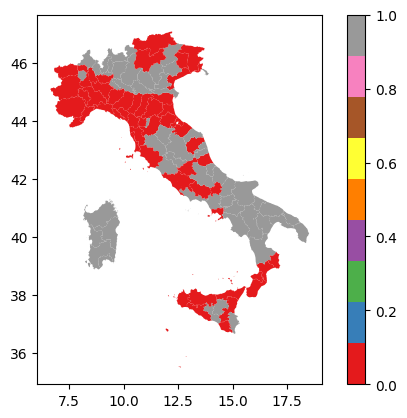

In [34]:
df["cluster"] = cluster_assignment

import geopandas as gpd
gdf = gpd.read_file("/Users/tommasobaresi/Desktop/Bayesian-Statistics-Project/Bayesian-Statistics-Project/data/updated_data.geojson")
gdf = gdf.merge(df[["prov_name", "cluster"]], on="prov_name", how="left")

gdf.plot(column="cluster", cmap="Set1", legend=True)
